## Adding in Epithelium-within-Epithelium Code

- I commented out the export stuff
- I'm pretty sure the function I created is returning contours in a manner that should work with this algorithm, but it's not currently creating any squares. I'm not sure why this is happening
- I also commented out the metrics because with no squares drawn, it throws a divide by 0 error

In [46]:
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

# slice_name = "h1849462  h&e_ROI_3.tif"
# slice_detail = "h&e_benign_case85_match1"
# mask_name = slice_detail + ".png"
# patched_slice_name = "output/patched_" + mask_name
# metrics_file_name = "output/metrics_before_improvement_" + slice_detail + ".csv"
# patch_length_filename = "output/patch_lengths_before_improvement" + slice_detail + ".csv"

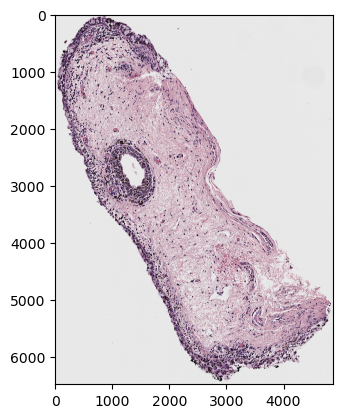

In [62]:
# Loading libraries and functions

import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv

# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

# Reading data
tissue_slice = cv2.cvtColor(cv2.imread("./images/tif_stains/h2114155 h&e_ROI_2.tif"), cv2.COLOR_BGR2RGB)
epithelium_mask = cv2.cvtColor(cv2.imread("./images/epithelium_extraction/export/h2114155 h&e_ROI_2-labels_1.png"), cv2.COLOR_BGR2RGB)
# tissue_slice = cv2.cvtColor(cv2.imread("./images/tif_stains/h2114153  h&e_4.tif"), cv2.COLOR_BGR2RGB)
# epithelium_mask = cv2.cvtColor(cv2.imread("./images/epithelium_extraction/export/h2114153  h&e_4-labels.png"), cv2.COLOR_BGR2RGB)
epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

def get_external_contours(epithelium_mask):
    epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
    # All pixels with a grayscale value above 127 converted to white, all below converted to black
    thresh = cv2.threshold(epithelium_mask_gray, 127, 255, 0)[1]
    # Get contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Create list to store masks
    masks = []
    # Finding the parent and child contours (excluding the contour that just does the rectangular borders of the image)
    parents = np.unique(hierarchy[0, :, 3])
    parents = parents[parents >= 0]
    children = np.argwhere(np.isin(hierarchy[0, :, 3], parents)).ravel()
    # Get object masks
    while children.size != 0:
        # Take first child (every contour is a child of something because findContours includes the border as the top of the hierarchy)
        current = children[0]
        # Remove from list of children
        children = np.delete(children, 0)
        # Draw contour
        mask = np.zeros_like(epithelium_mask_gray)
        cv2.drawContours(mask, contours, current, 255, 10)
        # If the current contour has any children, draw them on this mask as well
        # Imagine a donut, the first contour drawn will be the outer circle, this code then ensures that the inner circle is drawn too
        for j in np.argwhere(hierarchy[0, :, 3] == current).ravel():
            children = np.delete(children, np.argwhere(children == j))
            cv2.drawContours(mask, contours, j, 255, 15)
        masks.append(mask)

    # Because of the way Ryan's algorithm works, now need to return the external contours of the masks that were just created
    external_contours = []
    for mask in masks:
        contour, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        external_contours.append(contour[0])
    
    # Return list of external_contours
    return external_contours

# Getting contours
contours = get_external_contours(epithelium_mask)

# Getting tangents and normals on contour points
all_normals = []
all_tangents = []

# Predefine the smoothing parameter sizes
parameter_sizes = np.array([75, 100, 125, 150, 200])

for contour in contours:
    contour_points = contour.reshape(-1, 2)
    num_contour_points = len(contour_points)

    # Precompute indices for faster access
    prev_indices = (np.arange(num_contour_points)[:, None] - parameter_sizes) % num_contour_points
    next_indices = (np.arange(num_contour_points)[:, None] + parameter_sizes) % num_contour_points

    # Extract the actual contour points
    prev_points = contour_points[prev_indices]
    next_points = contour_points[next_indices]

    # Compute tangents
    tangents = next_points - prev_points
    tangents = tangents / (np.linalg.norm(tangents, axis=2, keepdims=True) + 1e-8)  

    # Take the mean along the smoothing dimension
    avg_tangents = np.mean(tangents, axis=1)

    # Normalize again
    avg_tangents = avg_tangents / (np.linalg.norm(avg_tangents, axis=1, keepdims=True) + 1e-8)

    # Compute normals
    normals = np.zeros_like(avg_tangents)
    normals[:, 0] = -avg_tangents[:, 1]
    normals[:, 1] = avg_tangents[:, 0]

    all_normals.append(normals)
    all_tangents.append(avg_tangents)
    
all_patches = []
all_patch_lengths = []
height, width = epithelium_mask_2D.shape

# Finding patch corners on each contour
for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    contour_normals = all_normals[c]
    contour_tangents = all_tangents[c]
    contour_patch_lengths = []
    squares = []

    contour_area = cv2.contourArea(contours[c])
    side_length = np.sqrt(contour_area)
    min_patch_length = side_length * 0.05  # squares at least 5% of area 
    max_patch_length = side_length * 0.50
    
    for i, point in enumerate(contour_points):
        point = point.astype(int)

        steps = np.arange(0, max_width, step_size)[:, None]
        normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

        pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

        stop = np.where(pixel_values == 0)[0]

        epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

        patch_length = int(epithelium_width * extension_factor)
        half_patch_length = patch_length // 2 

        if patch_length < min_patch_length or patch_length > max_patch_length:
            continue
        
        corners = np.array([
            point + (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
            point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
        ])
        squares.append(corners)
        contour_patch_lengths.append(patch_length)
    all_patches.append(squares)
    all_patch_lengths.append(contour_patch_lengths)

all_selected_patches = []
all_selected_patch_lengths = []

# Removing highly overlapping contours
for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    
    selected_patches = []
    selected_patch_lengths = []
    for i, point in enumerate(contour_points):
        if i >= len(all_patches[c]):  # Ensure index is in range
            continue

        current_patch = all_patches[c][i]
        current_patch_length = all_patch_lengths[c][i]
        if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold \
                 for ith_selected_patch in selected_patches):
            selected_patches.append(current_patch)
            selected_patch_lengths.append(current_patch_length)
    all_selected_patches.append(selected_patches)
    all_selected_patch_lengths.append(selected_patch_lengths)

selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)

# # Exporting patched slice
# cv2.imwrite(patched_slice_name, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

# Calculating performance metrics
total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

#For all patches in all contours, use them to create a mask
for contour_patches in all_selected_patches:
    for patch in contour_patches:
        patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(patch_mask, [patch], 255)

number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

# total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
# background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
# score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

# # Exporting performance metrics and parameter values
# metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
#                        'score', 'extension_factor', 'step_size',
#                        'max_width', 'overlap_threshold'], 
#               'Value':[total_epithelium_coverage, background_pixel_percent, score,
#                extension_factor, step_size, max_width, overlap_threshold]})

# metrics.to_csv(metrics_file_name, index=False)

# # Exporting patch lengths
# max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

# padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
#                for contour_patch_lengths in all_selected_patch_lengths]

# transposed_list = list(map(list, zip(*padded_list)))

# with open(patch_length_filename, mode='w', newline='') as file:
#     writer = csv.writer(file)
#     writer.writerows(transposed_list)

plt.imshow(selected_patches_on_slice);

In [63]:
print(f"Total Coverage: {total_epithelium_coverage:.2f}%")
print(f"Background Pixel Percentage: {background_pixel_percent:.2f}%")
print(f"Score Percentage: {score:.2f}%")

Total Coverage: 0.00%


NameError: name 'background_pixel_percent' is not defined